In [5]:
import pandas as pd
import numpy as np
import os
import sys

import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

"""
En caso de que Python no encuentre en la ruta los otros directorios,
ejecutar esta configuración
"""

sys.path.append(os.path.abspath(".."))

In [2]:
data_train = pd.read_csv("../../../dataset/Spotify_train_preprocesado_clasificacion.csv")

data_test = pd.read_csv("../../../dataset/Spotify_test_preprocesado_clasificacion.csv")

df_train = data_train.copy()
df_test = data_test.copy()

print("Dataset de entrenamiento: ")
display(df_train.head())


print("Dataset de pruebas: ")
display(df_test.head())

Dataset de entrenamiento: 


,bin__track_genre_0,bin__track_genre_1,bin__track_genre_2,bin__track_genre_3,bin__track_genre_4,bin__track_genre_5,bin__track_genre_6,ord__duration_category,num__danceability,num__energy,...,num__loudness,num__mode,num__speechiness,num__acousticness,num__instrumentalness,num__liveness,num__valence,num__tempo,num__duration_min,popularity_category
0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-0.360656,0.407609,0.005418,...,-0.557598,0.751125,-0.804229,0.532848,-0.562123,-0.436477,1.542740,-0.147610,-0.695300,1
1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.360656,0.100464,-0.034422,...,-0.017461,0.751125,-0.785413,0.623235,-0.606882,-0.678120,1.183864,0.437714,-0.191994,0
2,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.927115,-1.881489,0.216573,...,0.430609,0.751125,-0.519639,-0.618079,-0.580263,-0.985860,-1.305115,0.437984,0.625209,2
3,0.0,0.0,0.0,0.0,1.0,0.0,0.0,-0.360656,1.746296,0.336094,...,0.571210,-1.331337,-0.500823,-0.710274,-0.606882,-0.635477,-0.506326,0.064335,-0.879964,0
4,0.0,0.0,0.0,0.0,1.0,0.0,1.0,-0.360656,0.726344,-1.795371,...,-2.390784,-1.331337,1.124396,1.430692,1.793755,-0.671013,1.195440,2.664353,-0.772929,2


Dataset de pruebas: 


,bin__track_genre_0,bin__track_genre_1,bin__track_genre_2,bin__track_genre_3,bin__track_genre_4,bin__track_genre_5,bin__track_genre_6,ord__duration_category,num__danceability,num__energy,...,num__loudness,num__mode,num__speechiness,num__acousticness,num__instrumentalness,num__liveness,num__valence,num__tempo,num__duration_min,popularity_category
0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.927115,-1.452645,-1.914892,...,-2.318107,0.751125,-0.700742,1.813330,1.793755,-0.700153,-1.619613,-0.133029,1.330330,0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.360656,1.798453,0.626930,...,1.478109,0.751125,0.865678,-0.675324,-0.606764,1.390062,1.450127,-0.406397,-0.528812,0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.360656,0.639416,0.224541,...,0.842404,0.751125,-0.199770,-0.940037,-0.606785,-0.724317,1.303489,2.353574,-0.550148,0
3,1.0,0.0,0.0,0.0,1.0,1.0,0.0,-1.648427,-0.067596,0.754419,...,0.438615,0.751125,2.126046,1.707878,-0.606882,2.409939,0.292462,-1.350621,-1.566635,1
4,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.927115,0.830657,1.093063,...,1.257701,0.751125,-0.380872,-0.942719,1.793755,-1.048403,1.006355,0.096426,1.158399,0


In [3]:
X_train = df_train.drop(
    columns=["popularity_category"]
)

y_train = df_train["popularity_category"]

X_test = df_test.drop(
    columns=["popularity_category"]
)

y_test = df_test["popularity_category"]

In [6]:
nb_model = GaussianNB()

nb_model.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](5,)","[26966.,26966.,26966.,26966.,26966.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](5,)","[0.2,0.2,0.2,0.2,0.2]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[int64](5,)","[0,1,2,3,4]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,1.01e-09
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](20,)","['bin__track_genre_0','bin__track_genre_1','bin__track_genre_2',..., 'num__valence','num__tempo','num__duration_min']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,20
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](5, 20)","[[ 0.46, 0.51, 0.35,..., 0.03,-0.03,-0.02], [ 0.43, 0.45, 0.45,..., 0.07, 0.02, 0.01], [ 0.45, 0.38, 0.53,...,-0.12, 0.03, 0.04], [ 0.48, 0.41, 0.51,..., 0.04,-0.06,-0.06], [ 0.46, 0.56, 0.36,..., 0.11,-0.13,-0.16]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](5, 20)","[[0.25,0.25,0.23,...,1.05,1. ,1.16], [0.24,0.25,0.25,...,1.06,1.06,1.06], [0.25,0.24,0.25,...,0.95,0.96,0.92], [0.23,0.23,0.24,...,0.74,0.87,0.61], [0.21,0.21,0.19,...,0.71,0.75,0.4 ]]"


In [7]:
scoring = {
    "accuracy": "accuracy",
    "precision": "precision_weighted",
    "recall": "recall_weighted",
    "f1": "f1_weighted"
}

scores_nb = cross_validate(
    GaussianNB(),
    X_train,
    y_train,
    cv=5,
    scoring=scoring,
    n_jobs=-1
)

resultados_nb = {
    "Accuracy": scores_nb["test_accuracy"].mean(),
    "Precision": scores_nb["test_precision"].mean(),
    "Recall": scores_nb["test_recall"].mean(),
    "F1-Score": scores_nb["test_f1"].mean()
}

print("Resultados de Naive Bayes:")
for metrica, valor in resultados_nb.items():
    print(f"{metrica}: {valor:.4f}")

Resultados de Naive Bayes:
Accuracy: 0.3405
Precision: 0.3366
Recall: 0.3405
F1-Score: 0.3123


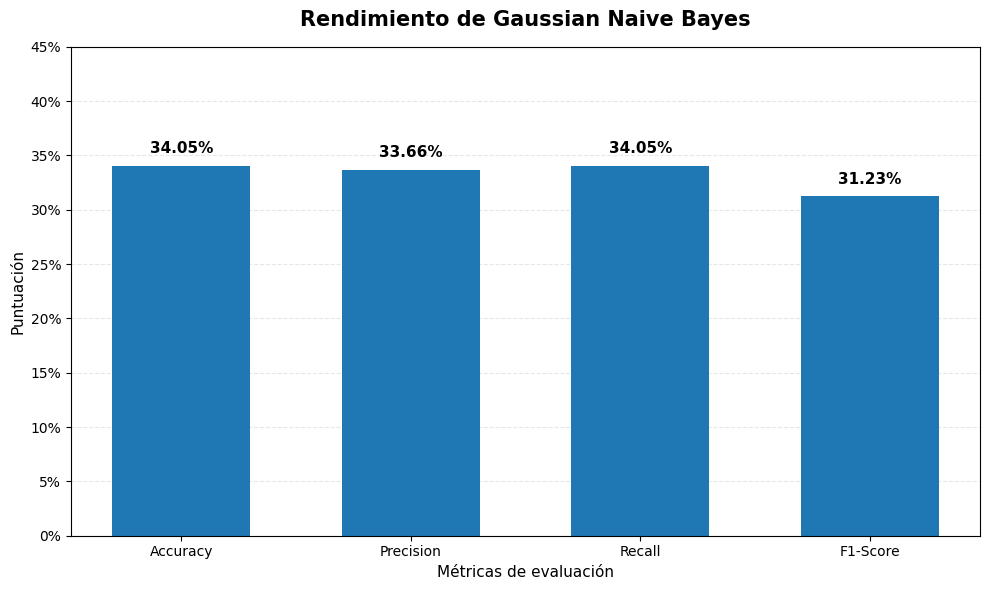

In [ ]:
# Métricas obtenidas durante la validación cruzada
metricas = {
    "Accuracy": scores_nb["test_accuracy"].mean(),
    "Precision": scores_nb["test_precision"].mean(),
    "Recall": scores_nb["test_recall"].mean(),
    "F1-Score": scores_nb["test_f1"].mean()
}

nombres = list(metricas.keys())
valores = list(metricas.values())

fig, ax = plt.subplots(figsize=(10, 6))

barras = ax.bar(nombres, valores, width=0.6)

# Mostrar el valor porcentual sobre cada barra
for barra, valor in zip(barras, valores):
    ax.annotate(
        f"{valor:.2%}",
        xy=(barra.get_x() + barra.get_width() / 2, barra.get_height()),
        xytext=(0, 7),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

# Configuración visual
ax.set_title(
    "Rendimiento del entrenamiento de Gaussian Naive Bayes",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Métricas de evaluación", fontsize=11)
ax.set_ylabel("Puntuación", fontsize=11)

ax.set_ylim(0, 0.45)
ax.set_yticks(np.arange(0, 0.46, 0.05))
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f"{y:.0%}")
)

ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()


In [9]:
# Entrenamiento definitivo
nb_model.fit(X_train, y_train)

# Predicciones sobre datos no vistos
y_pred_nb = nb_model.predict(X_test)

# Métricas finales
print(f"Accuracy: {accuracy_score(y_test, y_pred_nb):.4f}")

print(
    f"Precision: "
    f"{precision_score(y_test, y_pred_nb, average='weighted', zero_division=0):.4f}"
)

print(
    f"Recall: "
    f"{recall_score(y_test, y_pred_nb, average='weighted', zero_division=0):.4f}"
)

print(
    f"F1-Score: "
    f"{f1_score(y_test, y_pred_nb, average='weighted', zero_division=0):.4f}"
)

print("\nReporte de clasificación Gaussian Naive Bayes:")
print(
    classification_report(
        y_test,
        y_pred_nb,
        target_names=[
            "Muy baja",
            "Baja",
            "Media",
            "Alta",
            "Muy alta"
        ],
        zero_division=0
    )
)

Accuracy: 0.2401
Precision: 0.3810
Recall: 0.2401
F1-Score: 0.2816

Reporte de clasificación Gaussian Naive Bayes:
              precision    recall  f1-score   support

    Muy baja       0.40      0.33      0.36      6742
        Baja       0.42      0.23      0.30      6615
       Media       0.42      0.16      0.23      6615
        Alta       0.14      0.18      0.16      2522
    Muy alta       0.02      0.74      0.04       191

    accuracy                           0.24     22685
   macro avg       0.28      0.33      0.22     22685
weighted avg       0.38      0.24      0.28     22685

